In [3]:
from scipy.signal import stft
import scipy.stats

rzeczy do dodania:
- stft
- sk (spectral kurtosis)
- Jarque-Bera statistic
- KSS (Kolmogorov-Smirnov statistic)
- Anderson-Darling statistic
- QQplot (visual)
- local maxima selector

# dane testowe


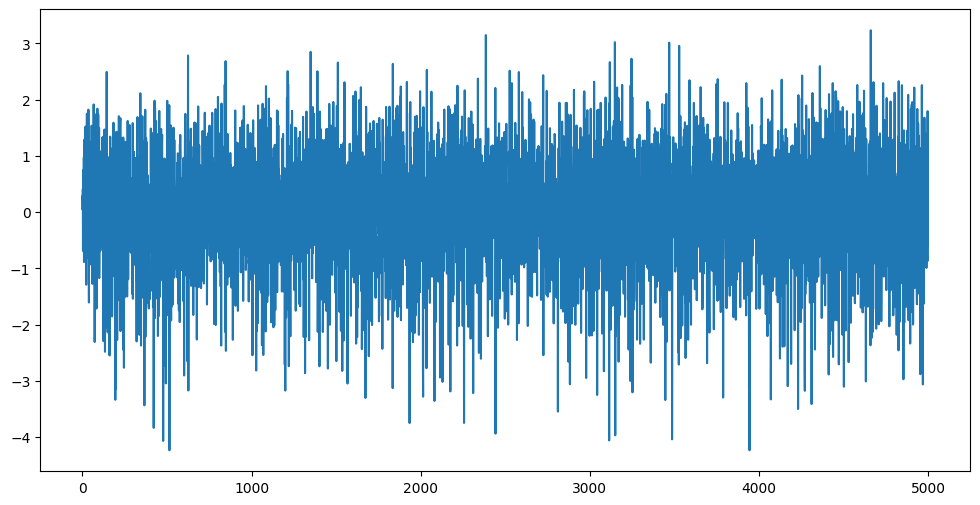

In [4]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

#częstotliwość próbkowania 1000Hz

data = loadmat('assets/vibration_dataset/versions/1/Healthy/H1.mat')
# sygnał jest wyrażony w trzech płaszczyznach X, Y, Z
signal = data['H'][:,1]
plt.figure(figsize = (12 , 6))
plt.plot(signal)


# Short term Fourier Transform

In [5]:
array_freq, array_tt, matrix_Zxx =stft(signal, fs = 1000, window = 'hann')
abs_Zxx = np.abs(matrix_Zxx)
# print(array_freq)
# print(array_tt)
# i = 5
# print(np.abs(matrix_Zxx[i]))
# plt.plot(np.abs(matrix_Zxx[i]))


# Spectral Kurtosis (SK)

In [6]:
def SK(Zxx,f,t):
    abs_Zxx = np.abs(Zxx)
    num = np.sum(np.pow(abs_Zxx[f,:],4))
    denum = np.sum(np.pow(abs_Zxx[f,:],2))
    T = len(t)
    return (T*num/denum)-2 

In [7]:
result = np.zeros_like(array_freq)

for i in range(0,len(array_freq)):
    print(f"Calculating SK for frequenzy {array_freq[i]}:")
    result[i] = SK(matrix_Zxx,i,array_tt)
    print(SK(matrix_Zxx,i,array_tt))

plt.plot(array_freq,result)

Calculating SK for frequenzy 0.0:


AttributeError: module 'numpy' has no attribute 'pow'

STFT analizuje, jak moc sygnału w danym paśmie zmienia się w czasie.

Jeśli ta moc zmienia się losowo, ale z rozkładem normalnym → SK ≈ 0.

Jeśli pojawiają się momenty, gdzie moc „wystrzela” (impulsowe zdarzenia) → SK > 0.

Jeśli sygnał jest bardzo „gładki” → SK < 0.

# Jarque–Bera test (JB)


In [8]:
def JB(Zxx, f, t):
    abs_Zxx = np.abs(Zxx)
    s = scipy.stats.skew(abs_Zxx[f])
    k = scipy.stats.kurtosis(abs_Zxx[f])
    T = len(t)
    print(f"Skewness: {s}, kurtosis: {k}")
    return T/6 * (s**2 + (np.power(k-1,2)/4))

for i in range(0,len(array_freq)):
    print(f"Calculating JB for frequenzy {array_freq[i]}:")
    print(f"JB statistic: {JB(matrix_Zxx,i,array_tt)}")

Calculating JB for frequenzy 0.0:
Skewness: 1.1315311262893635, kurtosis: 1.1279899670270916
JB statistic: 8.77712999245659
Calculating JB for frequenzy 3.90625:
Skewness: 0.5582628879962381, kurtosis: 0.659348524677712
JB statistic: 2.32790011166204
Calculating JB for frequenzy 7.8125:
Skewness: 0.3154618552308381, kurtosis: -0.6453497066607699
JB statistic: 5.304785658786993
Calculating JB for frequenzy 11.71875:
Skewness: 1.0995626758923651, kurtosis: 2.0890826829076303
JB statistic: 10.288016230247308
Calculating JB for frequenzy 15.625:
Skewness: 1.8848292330583982, kurtosis: 6.957365681676103
JB statistic: 84.90507347797946
Calculating JB for frequenzy 19.53125:
Skewness: 0.492854325016838, kurtosis: -0.07741185253698557
JB statistic: 3.6429146480114185
Calculating JB for frequenzy 23.4375:
Skewness: 0.8769129444012139, kurtosis: 1.464673098712196
JB statistic: 5.623536658871552
Calculating JB for frequenzy 27.34375:
Skewness: 0.526633554273094, kurtosis: -0.330239950278135
JB st

# Kolmogorov-Smirnov Statistic (KSS)

In [9]:
def KSS(Zxx,f,t):
    abs_Zxx = np.abs(Zxx)
    mean_signal = np.mean(abs_Zxx[f])
    std_signal = np.std(abs_Zxx[f])
    cdf_sample = np.zeros_like(t)
    for i in range(len(t)):
        cdf_sample[i] = scipy.stats.norm.cdf(t[i],loc=mean_signal, scale=std_signal)
    return(scipy.stats.kstest(abs_Zxx[f],cdf_sample))



In [ ]:
for i in range(0,len(array_freq)):
    print(f"Calculating KSS for frequenzy {array_freq[i]}:")
    p_value = KSS(matrix_Zxx,i,array_tt).pvalue
    print(f"KSS statistic: {p_value}")

Calculating KSS for frequenzy 0.0:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 3.90625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 7.8125:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 11.71875:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 15.625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 19.53125:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 23.4375:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 27.34375:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 31.25:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 35.15625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 39.0625:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 42.96875:
KSS statistic: 3.860780437752712e-22
Calculating KSS for frequenzy 46.875:
KSS statistic: 3.860780437752712e-22
Calculating KSS 

# Anderson Darling statistic(Q)

Tutaj będzie trzeba się trochę bardziej zagłębić w to, co jest zwracane w tej funkcji, bo nie ma bezpośrednio zwróconej p-wartości, tylko raczej wartości krytyczne(jeśli to nie jest to samo lol)

In [ ]:
for i in range(0,len(array_freq)):
    print(f"Calculating Q for frequenzy {array_freq[i]}:")
    result = scipy.stats.anderson(abs_Zxx[i], dist='norm')
    print(np.int64(result.statistic < result.critical_values[2]))


Calculating Q for frequenzy 0.0:
0
Calculating Q for frequenzy 3.90625:
1
Calculating Q for frequenzy 7.8125:
1
Calculating Q for frequenzy 11.71875:
1
Calculating Q for frequenzy 15.625:
0
Calculating Q for frequenzy 19.53125:
1
Calculating Q for frequenzy 23.4375:
1
Calculating Q for frequenzy 27.34375:
1
Calculating Q for frequenzy 31.25:
1
Calculating Q for frequenzy 35.15625:
0
Calculating Q for frequenzy 39.0625:
0
Calculating Q for frequenzy 42.96875:
0
Calculating Q for frequenzy 46.875:
1
Calculating Q for frequenzy 50.78125:
1
Calculating Q for frequenzy 54.6875:
1
Calculating Q for frequenzy 58.59375:
1
Calculating Q for frequenzy 62.5:
1
Calculating Q for frequenzy 66.40625:
1
Calculating Q for frequenzy 70.3125:
0
Calculating Q for frequenzy 74.21875:
1
Calculating Q for frequenzy 78.125:
1
Calculating Q for frequenzy 82.03125:
0
Calculating Q for frequenzy 85.9375:
1
Calculating Q for frequenzy 89.84375:
1
Calculating Q for frequenzy 93.75:
1
Calculating Q for frequenzy 9

# QQplot

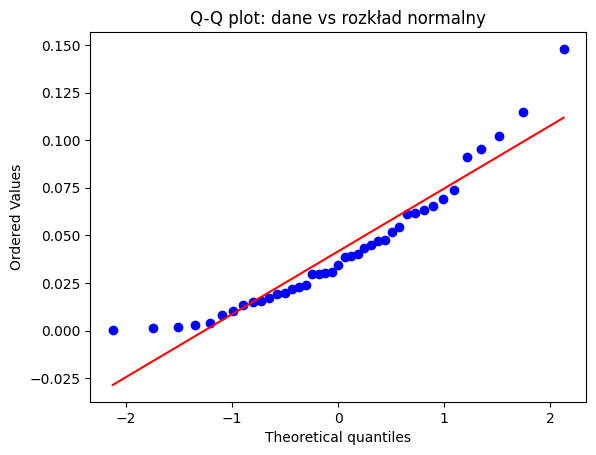

In [ ]:
temp = abs_Zxx[0]
scipy.stats.probplot(temp, dist="norm", plot=plt)
plt.title("Q-Q plot: dane vs rozkład normalny")
plt.show()

# Local maxima


In [ ]:
def M(matrix):
    
    maxima_row = (matrix[:,t] == np.max(matrix[:,t])).astype(int)
    print(maxima_row)
    print(f)
    return maxima_row[f]
    
def W(matrix_maxima,t,f):
    F = len(f)
    sum_result = 0
    for f_index in range(len(f)):
        sum_result += M(matrix_maxima,t,f_index)
    return 1/len(array_freq) * np.sum(matrix_maxima[:,t])

def ENH(matrix_maxima,t,f):
    return W(matrix_maxima,t,f)*M(matrix_maxima,t,f)

def LM(matrix_maxima,t,f):
    T = len(t)
    sum_result = 0
    for i in range(T):
        sum_result += ENH(matrix_maxima,i,f)
    return 1/T * sum_result

In [ ]:
abs_Zxx[:,0]

array([0.07400342, 0.05760407, 0.03482711, 0.04188244, 0.04594678,
       0.04304684, 0.03425474, 0.01773433, 0.02614063, 0.03920855,
       0.03474836, 0.03095819, 0.03843672, 0.03564652, 0.01871642,
       0.00371199, 0.0188457 , 0.02414261, 0.026586  , 0.02944721,
       0.02903095, 0.03271545, 0.04091252, 0.03925304, 0.02173905,
       0.00408064, 0.02300324, 0.02972822, 0.02715197, 0.02320347,
       0.0226109 , 0.02106539, 0.02195295, 0.03371324, 0.04804107,
       0.05607727, 0.05626522, 0.04836381, 0.0298468 , 0.00430779,
       0.02177058, 0.04021375, 0.04047213, 0.02218493, 0.03450453,
       0.05253325, 0.0452488 , 0.02683784, 0.02270969, 0.02934613,
       0.04143314, 0.04825979, 0.05127995, 0.05339429, 0.04369288,
       0.02981354, 0.03273005, 0.05043091, 0.06851816, 0.0716402 ,
       0.06000885, 0.04388891, 0.02757081, 0.02711245, 0.04452928,
       0.0546708 , 0.05320506, 0.04757882, 0.04273201, 0.03445157,
       0.0259184 , 0.03083736, 0.03735019, 0.03187125, 0.02042

In [18]:
def LM(f,matrix):
    # wiersze = częstotliwości, kolumny = ramki czasowe
    F = matrix.shape[0]
    T = matrix.shape[1]
    m_array = np.int64(matrix[f,:]==np.max(matrix[f,:]))

    lm_result = np.zeros_like(array_freq)

    for t in range(T):
        w_sum = np.zeros(T)
        for f_in in range(len(array_freq)):
            w_sum += np.int64(matrix[f_in,t]==np.max(matrix[f_in,:]))
        lm_result += m_array[t]*w_sum/len(array_freq)
    return lm_result

In [22]:
def LM(f, matrix):
    F = matrix.shape[0]
    T = matrix.shape[1]
    enh_sum = 0
    m_array = np.int64(matrix[f,:] == np.max(matrix[f,:]))
    for t in range(T):
        w_sum = 0
        for ff in range(F):
            w_sum += np.int64(matrix[ff,t] == np.max(matrix[f,:]))
        w_sum = w_sum/F
        enh_sum += w_sum*m_array[t]
    enh_sum = enh_sum/T
    return enh_sum

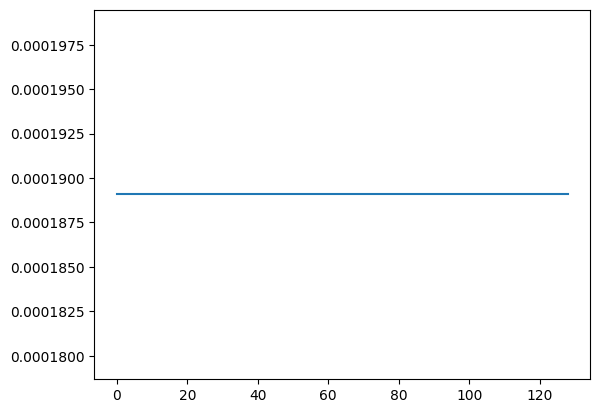

In [27]:
loc_res = np.zeros_like(array_freq)
for f in range(len(array_freq)):
    loc_res[f] = LM(f,abs_Zxx)

plt.plot(loc_res)

In [26]:
print(loc_res)

0.00018907165815844205
